# Creating the URIEL+ Dataset for the PCA Experiment

This notebook documents the steps used to create the URIEL+ dataset that will serve as the input to our PCA experiment.

Starting from the integrated linguistic databases, we progressively construct the feature matrix through aggregation and imputation. After each stage, we examine the amount of missing data to understand how the dataset changes throughout the pipeline.

The final output of this process is the imputed URIEL+ feature matrix that will be used for both ordinary PCA and phylogenetically-weighted PCA. Keeping this dataset fixed ensures that differences between the two PCA approaches are attributable to the feature-selection method rather than differences in missing-value handling.

## 1. Import Libraries

We first import the URIEL+ package and the libraries needed to load the generated `.npz` files, count missing values, and create the final visualization.

In [5]:
from URIELPlus.urielplus import urielplus

import numpy as np
import matplotlib.pyplot as plt

## 2. Helper Functions

The `load_data()` function loads the `data` array from a URIEL+ `.npz` file.

The `check_missing()` function reports:

- the matrix shape,
- the number of missing values,
- the total number of values, and
- the percentage of values represented by the `-1` missing-value sentinel.

This lets us inspect the matrix after each stage of the pipeline.

In [6]:
def load_data(file):
    npz_file = np.load(
        f'URIELPlus/urielplus/database/{file}',
        allow_pickle=True
    )
    return npz_file['data']


def check_missing(data, label):
    missing = np.sum(data == -1)
    total = data.size
    percentage = (missing / total) * 100

    print(f"\n{label}")
    print(f"Shape: {data.shape}")
    print(f"Missing values (-1): {missing:,}")
    print(f"Total values: {total:,}")
    print(f"Missing percentage: {percentage:.2f}%")

## 3. Initialize URIEL+

We create a fresh URIEL+ instance and reset it before configuring the experiment.

The cache mode is set to **True** so that URIEL+ data is actually saved to `.npz` files.

The aggregation mode is set to **union (`U`)**, meaning that information from the integrated sources is combined using the URIEL+ union aggregation strategy (an OR operation across feature sources).

In [7]:
# Initialize URIEL+

u = urielplus.URIELPlus()
u.reset()

# Configuration
u.set_cache(True)
u.set_aggregation('U')

2026-09-30 21:06:57,617 - root - INFO - c:\Users\User\Downloads\University\Fourth Year\Fall Semester\CSCI 3052U\Group Project\csci3052u-ml-project\URIELPlus\urielplus\database\family_features.npz is missing in "database". Copying from "original_uriel"...
2026-09-30 21:06:57,909 - root - INFO - c:\Users\User\Downloads\University\Fourth Year\Fall Semester\CSCI 3052U\Group Project\csci3052u-ml-project\URIELPlus\urielplus\database\features.npz is missing in "database". Copying from "original_uriel"...
2026-09-30 21:06:58,055 - root - INFO - c:\Users\User\Downloads\University\Fourth Year\Fall Semester\CSCI 3052U\Group Project\csci3052u-ml-project\URIELPlus\urielplus\database\geocoord_features.npz is missing in "database". Copying from "original_uriel"...
2026-09-30 21:06:58,134 - root - INFO - c:\Users\User\Downloads\University\Fourth Year\Fall Semester\CSCI 3052U\Group Project\csci3052u-ml-project\URIELPlus\urielplus\database\script_features.npz is missing in "database". Copying from "orig

## 4. Integrate the Linguistic Databases

Here we integrate the custom linguistic databases used to construct the working URIEL+ feature matrix.

We integrate all available URIEL+ linguistic databases except for eWAVE and Glottolog:

- **eWAVE** contributes 235 typological features describing grammatical properties specific to varieties of English. None of the languages in our working set have any observed eWAVE data, so including it would only add 235 fully-missing columns. We exclude it, leaving 593 typological features.
- **Glottolog** contributes almost 19,000 dialect entries with no typological data of their own; they exist solely as targets for BFS genetic imputation, receiving values copied down from a parent language. We exclude them so the working matrix contains only languages with independently sourced data.

In [8]:
u.integrate_custom_databases(
    "UPDATED_SAPHON",
    "BDPROTO",
    "GRAMBANK",
    "APICS"
)

2026-09-30 21:06:59,218 - root - INFO - Importing custom databases....
2026-09-30 21:06:59,219 - root - INFO - Importing updated SAPHON from "saphon_data.csv"....
2026-09-30 21:07:02,591 - root - INFO - Updated SAPHON integration complete..
2026-09-30 21:07:02,592 - root - INFO - Importing BDPROTO from "bdproto_data.csv"....
2026-09-30 21:07:02,593 - root - INFO - Converting ISO 639-3 codes to Glottocodes....
2026-09-30 21:07:03,384 - root - INFO - Conversion to Glottocodes complete.
2026-09-30 21:07:17,628 - root - INFO - BDPROTO integration complete.
2026-09-30 21:07:17,629 - root - INFO - Importing Grambank from "grambank_data.csv"....
2026-09-30 21:08:07,308 - root - INFO - Inferring feature data based on similar features.....
2026-09-30 21:08:08,467 - root - INFO - Feature inference complete.
2026-09-30 21:08:08,503 - root - INFO - Grambank integration complete.
2026-09-30 21:08:08,505 - root - INFO - Importing APiCS from "apics_data.csv"....
2026-09-30 21:08:24,674 - root - INFO 

## 5. Aggregate Without Base-Language Filling

First, we perform union aggregation **without** filling missing values from a base language.

This provides us the first snapshot of the feature matrix. At this point, a value of `-1` represents a feature value that is still missing.

We save this matrix as `data_post_aggregation` because it provides the reference point for determining which values were already known and which values were subsequently filled.

In [9]:
u.set_fill_with_base_lang(False)
u.aggregate()

data_post_aggregation = load_data("features_union.npz")

check_missing(
    data_post_aggregation,
    "After aggregation (before base-language filling)"
)

2026-09-30 21:08:28,513 - root - INFO - Creating union of data across sources....


2026-09-30 21:08:28,902 - root - INFO - Aggregation complete for idx=1.



After aggregation (before base-language filling)
Shape: (8128, 593, 1)
Missing values (-1): 4,055,676
Total values: 4,819,904
Missing percentage: 84.14%


## 6. Record Values Already Known After Aggregation

Before performing any further imputation, we record which cells are already known.

A cell is considered **originally known** if its value is not `-1`.

These cells form the first category in our final accounting.

In [10]:
originally_known = data_post_aggregation != -1

## 7. Aggregate With Base-Language Filling

Next, we repeat the aggregation with base-language filling enabled.

The purpose of this step is to fill values that were missing after aggregation by using **BFS genetic imputation**, where known values can be propagated from parent languages to related child languages.

In [11]:
u.set_fill_with_base_lang(True)
u.aggregate()

data_post_base_lang = load_data("features_union.npz")

check_missing(
    data_post_base_lang,
    "After base-language filling"
)

2026-09-30 21:08:29,029 - root - INFO - Creating union of data across sources....
2026-09-30 21:08:29,042 - root - INFO - Executing new BFS-based genetic imputation strategy...
2026-09-30 21:08:43,616 - root - INFO - Found 3020 root languages for genetic imputation.
2026-09-30 21:08:43,697 - root - INFO - Genetic imputation filled 59620 values.
2026-09-30 21:08:43,697 - root - INFO - Genetic imputation finished.
2026-09-30 21:08:43,754 - root - INFO - Aggregation complete for idx=1.



After base-language filling
Shape: (8128, 593, 1)
Missing values (-1): 3,996,056
Total values: 4,819,904
Missing percentage: 82.91%


## 8. Identify Values Filled by a Related Language

We now compare the matrices before and after base-language filling.

A cell belongs to this category when:

- it was `-1` before base-language filling, **and**
- it is no longer `-1` afterward.

These are the values that were newly filled during the base-language stage.

In [12]:
filled_by_base_lang = (
    (data_post_aggregation == -1) &
    (data_post_base_lang != -1)
)

## 9. Run SoftImpute

After aggregation and base-language filling, some feature values can still be missing.

We now run URIEL+'s SoftImpute step to fill the remaining missing values.

URIEL+'s `softimpute_imputation()` fills any values still missing after BFS genetic imputation, using SoftImpute. Like the rest of URIEL+'s typological data, the resulting values are binary (0 or 1).

In [13]:
u.softimpute_imputation()

data_post_imputation = load_data("features.npz")

check_missing(
    data_post_imputation,
    "After SoftImpute"
)

2026-09-30 21:08:55,971 - root - INFO - Starting imputation_interface
2026-09-30 21:08:56,021 - root - INFO - Creating union of data across sources....
2026-09-30 21:08:56,029 - root - INFO - Executing new BFS-based genetic imputation strategy...
2026-09-30 21:09:08,072 - root - INFO - Found 3020 root languages for genetic imputation.
2026-09-30 21:09:08,096 - root - INFO - Genetic imputation filled 0 values.
2026-09-30 21:09:08,097 - root - INFO - Genetic imputation finished.
2026-09-30 21:09:08,141 - root - INFO - Aggregation complete for idx=1.
c:\Users\User\anaconda3\envs\urielplus\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\User\anaconda3\envs\urielplus\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\User\anaconda

[SoftImpute] Max Singular Value of X_init = 235.197437
[SoftImpute] Iter 1: observed MAE=0.067894 rank=411
[SoftImpute] Iter 2: observed MAE=0.070124 rank=387
[SoftImpute] Iter 3: observed MAE=0.071558 rank=375
[SoftImpute] Iter 4: observed MAE=0.072551 rank=367
[SoftImpute] Iter 5: observed MAE=0.073179 rank=359
[SoftImpute] Iter 6: observed MAE=0.073446 rank=352
[SoftImpute] Iter 7: observed MAE=0.073506 rank=343
[SoftImpute] Iter 8: observed MAE=0.073514 rank=339
[SoftImpute] Iter 9: observed MAE=0.073512 rank=333
[SoftImpute] Iter 10: observed MAE=0.073508 rank=330
[SoftImpute] Iter 11: observed MAE=0.073503 rank=326
[SoftImpute] Iter 12: observed MAE=0.073495 rank=324
[SoftImpute] Iter 13: observed MAE=0.073488 rank=321
[SoftImpute] Iter 14: observed MAE=0.073480 rank=320
[SoftImpute] Iter 15: observed MAE=0.073473 rank=319
[SoftImpute] Iter 16: observed MAE=0.073467 rank=317
[SoftImpute] Iter 17: observed MAE=0.073460 rank=315
[SoftImpute] Iter 18: observed MAE=0.073452 rank=313


2026-09-30 21:15:24,797 - root - INFO - Time taken for softimpute (initial imputation): 375.7725651001092


[SoftImpute] Iter 211: observed MAE=0.073293 rank=295
[SoftImpute] Stopped after iteration 211 for lambda=4.703949


2026-09-30 21:15:27,292 - root - INFO - Largest difference in proportion: 0.5714285714285714
2026-09-30 21:15:27,293 - root - INFO - Average difference in proportion: 0.0897160542812766
2026-09-30 21:15:27,294 - root - INFO - Smallest difference in proportion: 0.0
2026-09-30 21:15:37,855 - root - INFO - Overall metrics for softimpute with hyperparameter None: {'accuracy': 0.8869690293683885, 'classification_error': 0.1130309706316115, 'precision': 0.8819666443634921, 'recall': 0.7197023316009787, 'f': 0.7926150282838181, 'largest_diff': 0.5714285714285714, 'average_diff': 0.0897160542812766, 'smallest_diff': 0.0, 'Q1 (0.02345058626465668)': 149, 'Q2 (0.06621004566210045)': 148, 'Q3 (0.13196480938416424)': 148, 'Q4 (0.5714285714285714)': 148}
2026-09-30 21:15:37,856 - root - INFO - Overall feature metrics for softimpute with hyperparameter None: {'S_': {'accuracy': 0.8497896677222668, 'classification_error': 0.15021033227773317, 'precision': 0.8664683523384564, 'recall': 0.6886903980034

...

[SoftImpute] Iter 27: observed MAE=0.015401 rank=19
[SoftImpute] Stopped after iteration 27 for lambda=4.175959


2026-09-30 21:21:30,806 - root - INFO - Largest difference in proportion: 0.01639344262295082
2026-09-30 21:21:30,807 - root - INFO - Average difference in proportion: 0.0045692065382606905
2026-09-30 21:21:30,809 - root - INFO - Smallest difference in proportion: 0.0
2026-09-30 21:21:31,532 - root - INFO - Overall metrics for softimpute with hyperparameter None: {'accuracy': 0.9940946738863838, 'classification_error': 0.0059053261136161606, 'precision': 0.9951792077132676, 'recall': 0.9831584759801215, 'f': 0.9891323217943822, 'largest_diff': 0.01639344262295082, 'average_diff': 0.0045692065382606905, 'smallest_diff': 0.0, 'Q1 (0.001434776005444687)': 10, 'Q2 (0.0032776338347226784)': 9, 'Q3 (0.005698143664245327)': 9, 'Q4 (0.01639344262295082)': 10}
2026-09-30 21:21:31,535 - root - INFO - Overall feature metrics for softimpute with hyperparameter None: {'SC_': {'accuracy': 0.9940946738863838, 'classification_error': 0.0059053261136161606, 'precision': 0.9951792077132676, 'recall': 0.

[SoftImpute] Max Singular Value of X_init = 257.695404
[SoftImpute] Iter 1: observed MAE=0.015690 rank=18
[SoftImpute] Iter 2: observed MAE=0.015713 rank=18
[SoftImpute] Iter 3: observed MAE=0.015715 rank=17
[SoftImpute] Iter 4: observed MAE=0.015711 rank=17
[SoftImpute] Iter 5: observed MAE=0.015710 rank=17
[SoftImpute] Iter 6: observed MAE=0.015711 rank=17
[SoftImpute] Iter 7: observed MAE=0.015713 rank=17
[SoftImpute] Iter 8: observed MAE=0.015715 rank=17
[SoftImpute] Iter 9: observed MAE=0.015716 rank=17
[SoftImpute] Iter 10: observed MAE=0.015717 rank=17
[SoftImpute] Iter 11: observed MAE=0.015718 rank=17
[SoftImpute] Iter 12: observed MAE=0.015718 rank=17
[SoftImpute] Iter 13: observed MAE=0.015719 rank=17
[SoftImpute] Iter 14: observed MAE=0.015719 rank=17
[SoftImpute] Iter 15: observed MAE=0.015719 rank=17
[SoftImpute] Iter 16: observed MAE=0.015720 rank=17
[SoftImpute] Iter 17: observed MAE=0.015720 rank=17


2026-09-30 21:21:52,292 - root - INFO - Time taken for softimpute (final imputation): 0.9817420998588204


[SoftImpute] Iter 18: observed MAE=0.015720 rank=17
[SoftImpute] Stopped after iteration 18 for lambda=5.153908

After SoftImpute
Shape: (8128, 593, 1)
Missing values (-1): 0
Total values: 4,819,904
Missing percentage: 0.00%


## 10. Identify Values Filled by SoftImpute

We compare the matrix after base-language filling with the final matrix after SoftImpute.

A cell belongs to this category when:

- it was still `-1` after base-language filling, **and**
- it has a value after SoftImpute.

This isolates the values that required the final imputation stage.

In [14]:
filled_by_softimpute = (
    (data_post_base_lang == -1) &
    (data_post_imputation != -1)
)

## 11. Count Each Category

We count the number of feature cells belonging to each category.

The three categories should partition the final matrix:

- values known after aggregation,
- values filled using a related/base language, and
- values filled by SoftImpute.

In [15]:
originally_known_count = np.sum(originally_known)
base_lang_count = np.sum(filled_by_base_lang)
softimpute_count = np.sum(filled_by_softimpute)

total = data_post_imputation.size

## 12. Final Breakdown

We convert the counts into percentages of the complete final matrix.

This provides us a direct summary of where the final feature values came from.

In [16]:
print("Final breakdown")

print(
    f"Known after aggregation:       "
    f"{originally_known_count:,} "
    f"({originally_known_count / total * 100:.2f}%)"
)

print(
    f"Filled by related language:     "
    f"{base_lang_count:,} "
    f"({base_lang_count / total * 100:.2f}%)"
)

print(
    f"Filled by SoftImpute:           "
    f"{softimpute_count:,} "
    f"({softimpute_count / total * 100:.2f}%)"
)

print(f"Total data points:              {total:,}")

Final breakdown
Known after aggregation:       764,228 (15.86%)
Filled by related language:     59,620 (1.24%)
Filled by SoftImpute:           3,996,056 (82.91%)
Total data points:              4,819,904


## 13. Validate the Classification

To validate consistency, we add the three categories together.

If the result equals the total number of feature cells, then every final data point has been assigned to exactly one category.

If the counts do not match, something in the classification logic needs to be investigated.

In [17]:
classified = (
    originally_known_count
    + base_lang_count
    + softimpute_count
)

print(f"\nClassified data points:         {classified:,}")

if classified == total:
    print("All data points accounted for.")
else:
    print("WARNING: Data point counts do not add up!")


Classified data points:         4,819,904
All data points accounted for.


## 14. Prepare the Visualization

Finally, we prepare a pie chart showing the composition of the final URIEL+ feature matrix.

Each section represents one source of the final values, while the centre displays the total number of feature cells.

In [18]:
labels = [
    "Known after aggregation",
    "Filled by related language",
    "Filled by SoftImpute"
]

sizes = [
    originally_known_count,
    base_lang_count,
    softimpute_count
]

percentages = [
    value / total * 100
    for value in sizes
]


def autopct_with_count(pct):
    count = int(round(pct * total / 100))
    return f"{pct:.1f}%\n({count:,})" 

## 15. Create the Pie Chart

The pie chart provides a visual summary of how the final matrix was constructed.

The legend includes both the raw count and percentage for each category, making the figure useful for reporting the feature-coverage results.

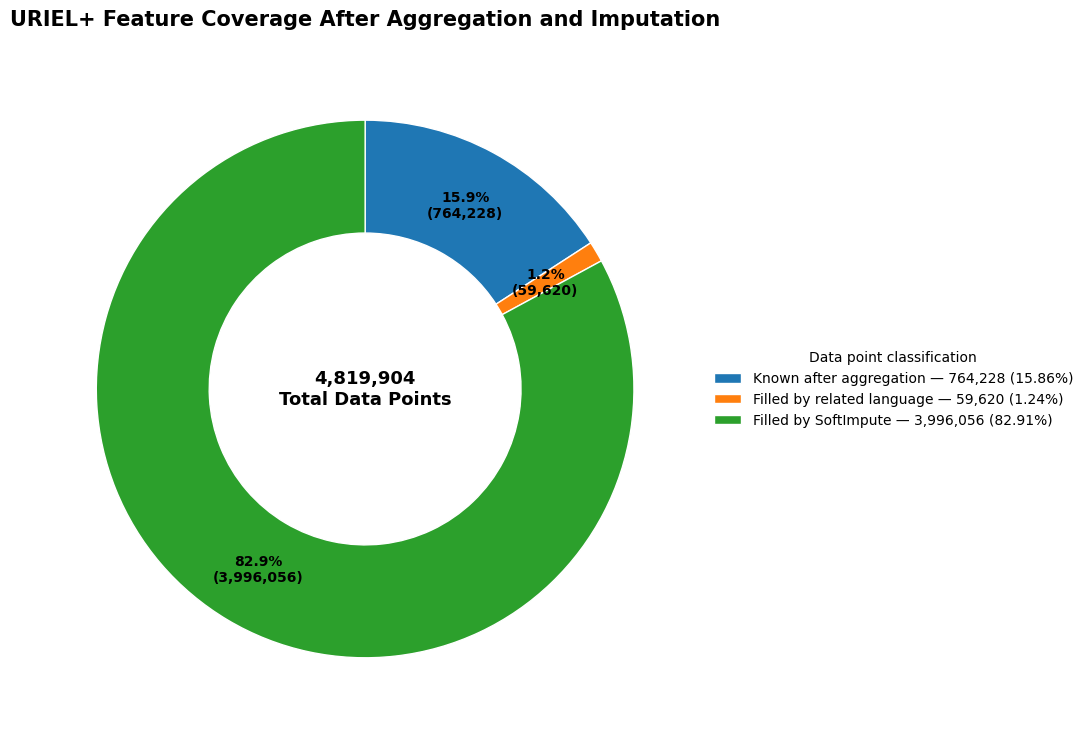

In [19]:
fig, ax = plt.subplots(figsize=(10, 8))

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=None,
    autopct=autopct_with_count,
    startangle=90,
    counterclock=False,
    pctdistance=0.78,
    wedgeprops=dict(width=0.42, edgecolor="white")
)


# Improve percentage/count text
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight("bold")


# Center text
ax.text(
    0,
    0,
    f"{total:,}\nTotal Data Points",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold"
)


# Legend
legend_labels = [
    f"{label} — {count:,} ({percentage:.2f}%)"
    for label, count, percentage
    in zip(labels, sizes, percentages)
]

ax.legend(
    wedges,
    legend_labels,
    title="Data point classification",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    frameon=False
)


ax.set_title(
    "URIEL+ Feature Coverage After Aggregation and Imputation",
    fontsize=15,
    fontweight="bold",
    pad=20
)

ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## 16. Package the URIEL+ Database

In [20]:
import os
import zipfile

database_dir = "URIELPlus/urielplus/database"
output_zip = "data.zip"

excluded_folders = {
    "original_uriel",
    "urielplus_csvs"
}

files_added = []

with zipfile.ZipFile(output_zip, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(database_dir):

        dirs[:] = [
            directory
            for directory in dirs
            if directory not in excluded_folders
        ]

        for filename in files:
            file_path = os.path.join(root, filename)

            if filename == "__init__.py":
                continue

            if os.path.abspath(file_path) == os.path.abspath(output_zip):
                continue

            archive_path = os.path.relpath(
                file_path,
                database_dir
            )

            zipf.write(
                file_path,
                arcname=archive_path
            )

            files_added.append(file_path)

for file_path in files_added:
    os.remove(file_path)

print(f"Created: {output_zip}")
print(f"Files added to ZIP: {len(files_added)}")
print("\nFiles packaged:")

for file_path in files_added:
    print(f"  - {os.path.relpath(file_path, database_dir)}")

print("\nExcluded folders:")
for folder in sorted(excluded_folders):
    print(f"  - {folder}")

Created: data.zip
Files added to ZIP: 11

Files packaged:
  - family_features.npz
  - features.npz
  - features_union.npz
  - geocoord_features.npz
  - imputation_metrics_script.csv
  - imputation_metrics_typological.csv
  - script_features.npz
  - script_features_union.npz
  - __init__.py
  - non_imputed_data\features.npz
  - non_imputed_data\script_features.npz

Excluded folders:
  - original_uriel
  - urielplus_csvs


## Summary

This notebook reconstructs the URIEL+ feature matrix used in the PCA experiment, tracking how missing data changes at each stage of the pipeline: after union aggregation, after BFS genetic imputation, and after SoftImpute.

The final breakdown distinguishes between values that were:

- already present after source integration and union aggregation,
- supplied through related/base-language information (BFS genetic imputation), and
- supplied by SoftImpute.

The pie chart visualizes this breakdown directly, showing what fraction of the final matrix reflects genuinely sourced typological data versus values filled in during preprocessing.